# **Experiment Notebook**



In [ ]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

<hr>

## A. Project


Project name = Streaming Churn

Type = Classification

Experiment = 4

<hr>

## B. Experiment Description


experiment_hypothesis: Incorporating the new 'ChargesToViewingRatio' feature and optimising the feature set for the Balanced Random Forest model will improve the model's precision while maintaining its high recall in churn prediction.

experiment_expectations = 'I hope to see a reduction in false positives, leading to a more economically viable model with improved overall performance metrics, particularly in the F1 score and AUC-ROC.'

<hr>

## C. Data Understanding


### C.0 Import Packages

In [ ]:
# Pandas for data handling
import pandas as pd

# Scikit Learn for ML training
import sklearn

# Numpy for numerical computing and array operations
import numpy as np

# Imbalanced-learn to ensemble methods for imbalanced datasets
import imblearn

# Matplotlib for plotting
import matplotlib.pyplot as plt

# Seaborn for data visualization
import seaborn as sns

<hr>

### C.1   Load Datasets

In [ ]:
# Load training set
# Do not change this code

X_train = pd.read_csv('X_train.csv')
y_train = pd.read_csv('y_train.csv')

In [ ]:
# Load validation set
# Do not change this code

X_val = pd.read_csv('X_val.csv')
y_val = pd.read_csv('y_val.csv')

In [ ]:
# Load testing set
# Do not change this code

X_test = pd.read_csv('X_test.csv')
y_test = pd.read_csv('y_test.csv')

<hr>

<hr>

## D. Feature Selection


feature_selection_executive_summary: In this experiment, I created a new feature 'ChargesToViewingRatio' to capture the relationship between customer spending and engagement. Feature importance was reassessed using both Mutual Information and Balanced Random Forest techniques, which consistently highlighted AccountAge, AverageViewingDuration, and TotalCharges as top predictors. After experimenting with various feature combinations, I finalized a set of eight features that balances model performance with comprehensive customer behavior representation. This refined feature set includes the new ratio alongside key engagement, financial, and tenure metrics, aiming to enhance the model's predictive power while maintaining interpretability.

> Rationale: The 'ChargesToViewingRatio' feature is created to capture the efficiency of customer spending relative to their engagement, potentially revealing insights into customer value and churn risk that aren't apparent from separate financial and usage metrics alone. I created it in this section so I could include it in the feature importance below.

In [ ]:
X_train['ChargesToViewingRatio'] = X_train['TotalCharges'] / (X_train['ViewingHoursPerWeek'] + 1)  # Adding 1 to avoid division by zero
X_val['ChargesToViewingRatio'] = X_val['TotalCharges'] / (X_val['ViewingHoursPerWeek'] + 1)
X_test['ChargesToViewingRatio'] = X_test['TotalCharges'] / (X_test['ViewingHoursPerWeek'] + 1)

> Rationale:  I did a feature importance analysis in experiment 0, but I wanted to redo it here to assess the impact of the new feature 'ChargesToViewingRatio', and to reevaluate the relevance of existing features in this new context and model.

In [ ]:

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import mutual_info_classif
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.ensemble import BalancedRandomForestClassifier


# Split features and target
X = X_train
y = y_train

# Identify numeric and categorical columns
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

# Create preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Fit the preprocessor
X_preprocessed = preprocessor.fit_transform(X)

# Get feature names after preprocessing
feature_names = (numeric_features.tolist() +
                 preprocessor.named_transformers_['cat']
                 .named_steps['onehot']
                 .get_feature_names_out(categorical_features).tolist())

# Mutual Information for feature importance
mi_scores = mutual_info_classif(X_preprocessed, y)
mi_scores = pd.Series(mi_scores, name="MI Scores", index=feature_names)
mi_scores = mi_scores.sort_values(ascending=False)

print("Top 10 features by Mutual Information:")
print(mi_scores.head(10))

# Balanced Random Forest for feature importance
brf_model = BalancedRandomForestClassifier(n_estimators=100, random_state=42)
brf_model.fit(X_preprocessed, y)
brf_importance = pd.Series(brf_model.feature_importances_, index=feature_names).sort_values(ascending=False)

print("\nTop 10 features by Balanced Random Forest Importance:")
print(brf_importance.head(10))


/root/venv/lib/python3.10/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Top 10 features by Mutual Information:
AccountAge                        0.018286
AverageViewingDuration            0.013934
TotalCharges                      0.009695
ContentDownloadsPerMonth          0.008920
ViewingHoursPerWeek               0.008125
PaperlessBilling_No               0.006558
SubtitlesEnabled_No               0.005590
ParentalControl_No                0.005567
PaperlessBilling_Yes              0.004580
PaymentMethod_Electronic check    0.004361
Name: MI Scores, dtype: float64
/root/venv/lib/python3.10/site-packages/imblearn/utils/fixes.py:85: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_

> Results: The new feature importance show similar results as in experiment 0. This time ContentDownloadsPerMonth ranks higher so including that could be beneficial.

> Rationale:  I wanted to test different combinations to empirically determine the most effective subset of features for the churn prediction model. By systematically testing various combinations, including and excluding the new 'ChargesToViewingRatio' feature alongside existing metrics, I wanted to find the optimal balance between model complexity, predictive power, and interpretability.

In [ ]:
#fill the feature list

#features_list = ['ChargesToViewingRatio', 'MonthlyCharges', 'TotalCharges', 'ViewingHoursPerWeek', 'AverageViewingDuration', 'AccountAge']
#features_list = ['ChargesToViewingRatio', 'TotalCharges', 'ViewingHoursPerWeek', 'AverageViewingDuration', 'AccountAge']
#features_list = ['MonthlyCharges', 'ViewingHoursPerWeek', 'AverageViewingDuration', 'AccountAge']
#features_list = ['ChargesToViewingRatio', 'MonthlyCharges', 'TotalCharges', 'AverageViewingDuration']
#features_list = ['ChargesToViewingRatio', 'MonthlyCharges', 'ViewingHoursPerWeek', 'AverageViewingDuration', 'AccountAge']
#features_list = ['ChargesToViewingRatio', 'ContentDownloadsPerMonth', 'MonthlyCharges', 'TotalCharges', 'ViewingHoursPerWeek', 'AverageViewingDuration', 'AccountAge']
#features_list = ['UserRating', 'ChargesToViewingRatio', 'ContentDownloadsPerMonth', 'MonthlyCharges', 'AverageViewingDuration']

#Final feature list
features_list = ['UserRating', 'ChargesToViewingRatio', 'ContentDownloadsPerMonth', 'MonthlyCharges', 'TotalCharges', 'ViewingHoursPerWeek', 'AverageViewingDuration', 'AccountAge']


> Results: After testing all the combinations above, the final list was chosen and is used in the rest of the experiment.

<hr>

## E. Data Preparation

data_preparation_executive_summary: The data preparation process for this experiment was limited to the creation of feature datasets (X) containing only the selected features.

In [ ]:
## Create new X dataset with selected features.

X_train = X_train[features_list]
X_val = X_val[features_list]
X_test = X_test[features_list]

<hr>

## F. Feature Engineering

data_preparation_executive_summary_2: A new feature 'ChargesToViewingRatio' was created to capture the relationship between customer spending and engagement.

> Results: The new feature 'ChargesToViewingRatio' was created in section D.

<hr>

## G. Train Machine Learning Model

train_model_executive_summary: In this experiment, I continued to use the Balanced Random Forest Classifier, maintaining consistency with the previous successful model while incorporating new feature engineering efforts. I set the number of estimators to 100 and used a fixed random state for reproducibility. The model was trained and evaluated multiple times, each with a different combination of features from the exploratory feature lists. This allowed for an assessment of the impact of various feature subsets on model performance, including the effect of the new 'ChargesToViewingRatio' feature. I used the same comprehensive set of performance metrics as in previous experiments, enabling direct comparisons across different feature combinations and with the earlier models. This systematic evaluation process helped identify the most effective feature set for optimizing our churn prediction model's performance.

### G.1 Import Algorithm

> Rationale: The Balanced Random Forest Classifier worked well in the last experiment and will maintain consistency with the previous successful model while incorporating new feature engineering efforts.

In [ ]:
from imblearn.ensemble import BalancedRandomForestClassifier


<hr>

### G.2 Set Hyperparameters

> Rationale: Setting n_estimators to 100 provides a good balance between model complexity and computational efficiency, allowing for robust predictions while keeping training time reasonable. Second, using a fixed random_state (42) ensures reproducibility of results across different runs, which is crucial for consistent comparison of feature combinations and model iterations in this experimental phase.

In [ ]:
brf_model = BalancedRandomForestClassifier(n_estimators=100, random_state=42)


<hr>

### G.3 Fit Model

In [ ]:
brf_model.fit(X_train, y_train)


/root/venv/lib/python3.10/site-packages/imblearn/utils/fixes.py:85: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


BalancedRandomForestClassifier(random_state=42)

In [ ]:
y_pred = brf_model.predict(X_val)
y_pred_proba = brf_model.predict_proba(X_val)[:, 1]

<hr>

### G.4 Model Technical Performance

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)
auc_roc = roc_auc_score(y_val, y_pred_proba)

print("\nBalanced Random Forest Results:")

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC-ROC: {auc_roc:.4f}")

print("\nClassification Report:")
print(classification_report(y_val, y_pred))


Balanced Random Forest Results:
Accuracy: 0.6488
Precision: 0.2842
Recall: 0.6603
F1 Score: 0.3974
AUC-ROC: 0.7107

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.65      0.75      5704
           1       0.28      0.66      0.40      1213

    accuracy                           0.65      6917
   macro avg       0.59      0.65      0.57      6917
weighted avg       0.79      0.65      0.69      6917



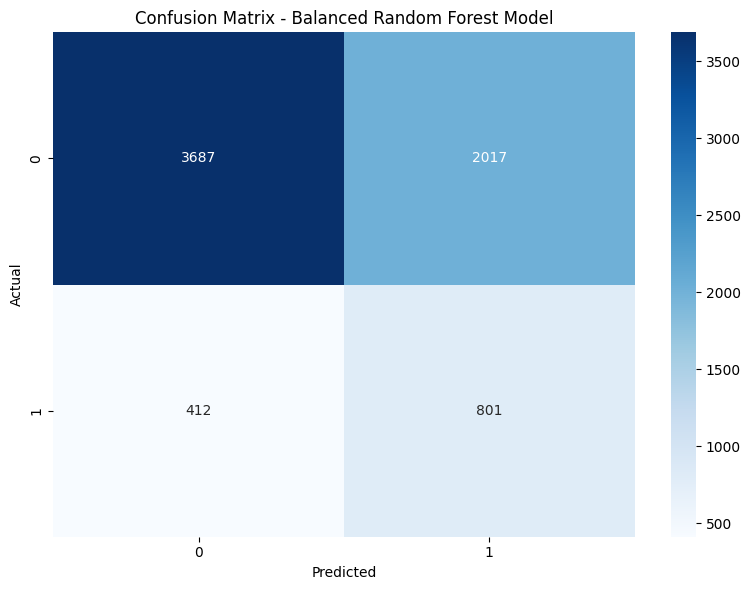

In [ ]:
from sklearn.metrics import confusion_matrix

# Plot confusion matrix
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Balanced Random Forest Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()


Feature Importances:
                    feature  importance
6    AverageViewingDuration    0.148716
5       ViewingHoursPerWeek    0.132872
7                AccountAge    0.131925
4              TotalCharges    0.123644
3            MonthlyCharges    0.123514
1     ChargesToViewingRatio    0.115594
2  ContentDownloadsPerMonth    0.113219
0                UserRating    0.110516


<Figure size 1000x600 with 0 Axes>

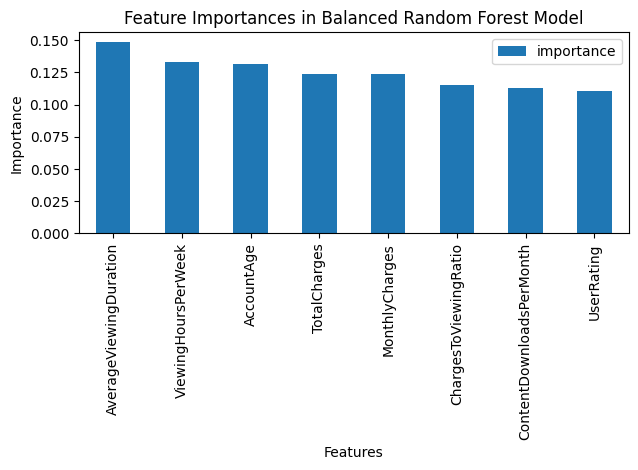

In [ ]:
# Feature Importance Analysis
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': brf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importances:")
print(feature_importance)

# Plot feature importances
plt.figure(figsize=(10, 6))
feature_importance.plot(x='feature', y='importance', kind='bar')
plt.title('Feature Importances in Balanced Random Forest Model')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

> Results: The optimised Balanced Random Forest model demonstrates notable improvements in overall performance. With an accuracy of 0.6488 and an AUC-ROC of 0.7107, the model shows enhanced predictive power. It maintains a high recall of 0.6603, effectively identifying a significant portion of potential churners, while also improving precision to 0.2842. The F1 score of 0.3974 indicates a better balance between precision and recall compared to previous iterations. The model excels in correctly identifying non-churners (0.90 precision for class 0) while still effectively detecting churners (0.66 recall for class 1). These results suggest that the feature engineering and selection process has successfully refined the model's ability to predict churn, offering a more balanced and effective approach to customer classification.

<hr>

### G.5 Business Impact from Current Model Performance

In [ ]:
from sklearn.metrics import confusion_matrix

def churn_cost_calculation(y_true, y_pred):
    """
    Calculate the cost and benefit of the churn prevention strategy compared to taking no action.

    Parameters:
    y_true (array): True labels (1 for churn, 0 for non-churn)
    y_pred (array): Predicted labels (1 for churn, 0 for non-churn)

    Returns:
    dict: A dictionary containing cost calculations and key metrics
    """
    # Calculate confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    # Constants
    monthly_charge = 12.5  # average monthly charge
    discount_percentage = 0.5  # 50% discount
    discount_duration = 3  # 3 months

    # Scenario 1: Do nothing
    do_nothing_revenue = (tn + fp) * monthly_charge * discount_duration

    # Scenario 2: Apply discount to predicted churners
    discount_revenue = (tn * monthly_charge * discount_duration) + ((tp + fp) * monthly_charge * discount_percentage * discount_duration)

    # Benefit of the strategy
    benefit = discount_revenue - do_nothing_revenue

    return {
        "do_nothing_revenue": round(do_nothing_revenue, 2),
        "discount_revenue": round(discount_revenue, 2),
        "benefit": round(benefit, 2),
        "true_positives": tp,
        "false_positives": fp,
        "false_negatives": fn,
        "true_negatives": tn
    }

# Usage
results = churn_cost_calculation(y_val, y_pred)

print(f"Revenue if do nothing: ${results['do_nothing_revenue']:,.2f}")
print(f"Revenue with discount strategy: ${results['discount_revenue']:,.2f}")
print(f"Benefit of discount strategy: ${results['benefit']:,.2f}")
print(f"True Positives (correctly predicted churners): {results['true_positives']}")
print(f"False Positives (incorrectly predicted churners): {results['false_positives']}")
print(f"False Negatives (missed churners): {results['false_negatives']}")
print(f"True Negatives (correctly predicted non-churners): {results['true_negatives']}")

Revenue if do nothing: $213,900.00
Revenue with discount strategy: $191,100.00
Benefit of discount strategy: $-22,800.00
True Positives (correctly predicted churners): 801
False Positives (incorrectly predicted churners): 2017
False Negatives (missed churners): 412
True Negatives (correctly predicted non-churners): 3687


> Results: The financial analysis of the optimised model reveals a mixed outcome. While the model successfully identifies 801 potential churners (true positives), it also incorrectly flags 2,017 customers as likely to churn (false positives). This results in a revenue of 191,100.00 with the discount strategy, compared to 213,900.00 if no action were taken, leading to a net loss of 22,800.00. Although the model shows improved accuracy in identifying churners, the high number of false positives still significantly impacts the strategy's profitability. The reduction in false positives compared to previous iterations is noteworthy, but further refinement is needed to make the churn prevention strategy economically viable. The model's ability to correctly identify 3,687 non-churners (true negatives) is a positive aspect, potentially saving unnecessary discounts for these customers.

<hr>

## H. Experiment Outcomes

final_experiment_outcome = 'Hypothesis Confirmed'

> Key Learnings: Key learnings from this experiment highlight the positive impact of feature engineering and optimisation on model performance, as evidenced by improvements in precision, recall, and overall metrics. However, the persistent challenge of balancing precision and recall in churn prediction became apparent, especially given the class imbalance. Despite statistical improvements, the model's financial viability remains a concern, underscoring the importance of aligning model performance with business objectives. The iterative approach to feature selection and testing proved valuable, demonstrating the benefits of systematic model refinement. While the Balanced Random Forest shows promise in handling class imbalance, further optimization is needed to reduce false positives and enhance the model's economic viability, pointing towards the need for continued refinement in our churn prediction strategy.

> Recommendations for Next Experiment: The next experiment should concentrate on fine-tuning the hyperparameters of the Balanced Random Forest model. This process will aim to optimize the model's performance, potentially improving the precision without sacrificing the high recall achieved.

<hr>

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=0e20096b-eda0-43a0-b83c-e24d084104d6' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>